In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Exercise 8-1
- Illustrate using python that $(A^{-1})^{-1} = A$

In [12]:
A = np.trunc(np.random.default_rng().random((4, 4)) * 10 **3) / 10**3
A

array([[0.482, 0.187, 0.447, 0.178],
       [0.631, 0.427, 0.755, 0.23 ],
       [0.761, 0.855, 0.128, 0.823],
       [0.896, 0.465, 0.049, 0.952]])

In [18]:
# While not exact due to rounding errors this shows that the inverse of the inverse is the original matrix
np.trunc(np.linalg.inv(np.linalg.inv(A)) * 10 ** 3) / 10**3 - A

array([[-0.001,  0.   , -0.001,  0.   ],
       [ 0.   ,  0.   , -0.001,  0.   ],
       [-0.001, -0.001, -0.001, -0.001],
       [-0.001, -0.001, -0.001, -0.001]])

# Exercise 8-2
- Implement full "inverting any square full-rank matrix" algo

In [30]:
A = np.random.default_rng().random((4, 4))
A

array([[0.88470284, 0.34774797, 0.20997003, 0.05637225],
       [0.05716204, 0.95304091, 0.20831214, 0.66490392],
       [0.34090445, 0.85992446, 0.02686301, 0.51418276],
       [0.55347299, 0.35540732, 0.45486333, 0.63240455]])

In [55]:
row_count = A.shape[0]
col_count = A.shape[1]

minors_matrix = np.zeros((row_count, col_count))

for row_idx in range(row_count):
    for col_idx in range(col_count):
        row_mask = np.arange(A.shape[0]) != row_idx
        col_mask = np.arange(A.shape[1]) != col_idx
        sum_matrix = A[row_mask][:, col_mask]
        minors_matrix[row_idx][col_idx] = np.linalg.det(sum_matrix)
minors_matrix

array([[-0.02819804,  0.09519224, -0.1495014 , -0.18570641],
       [-0.12972806, -0.16949679,  0.32343825,  0.21435586],
       [-0.11602968, -0.08637503,  0.41096372,  0.24258419],
       [ 0.03954217,  0.11646458, -0.01924818, -0.16956559]])

In [61]:
grid_matrix = np.zeros((row_count, col_count))
for row_idx in range(row_count):
    for col_idx in range(col_count):
        grid_matrix[row_idx][col_idx] = (-1)**(row_idx +col_idx + 2)
grid_matrix

array([[ 1., -1.,  1., -1.],
       [-1.,  1., -1.,  1.],
       [ 1., -1.,  1., -1.],
       [-1.,  1., -1.,  1.]])

In [62]:
cofactors_matrix = minors_matrix * grid_matrix
cofactors_matrix

array([[-0.02819804, -0.09519224, -0.1495014 ,  0.18570641],
       [ 0.12972806, -0.16949679, -0.32343825,  0.21435586],
       [-0.11602968,  0.08637503,  0.41096372, -0.24258419],
       [-0.03954217,  0.11646458,  0.01924818, -0.16956559]])

In [70]:
adjunct_matrix = cofactors_matrix.T * np.linalg.det(A)**(-1)
adjunct_matrix

array([[ 0.35706409, -1.64271126,  1.46925243,  0.50071174],
       [ 1.20539361,  2.14629195, -1.09374366, -1.47475939],
       [ 1.89309576,  4.09561096, -5.20392223, -0.24373444],
       [-2.35154994, -2.71433024,  3.07177794,  2.14716312]])

In [72]:
# Given the adjunct matrix is the inverse of A this should roughly be the identity matrix. It is but with rounding errors
adjunct_matrix @ A

array([[ 1.00000000e+00,  2.22044605e-16,  1.24900090e-16,
         1.11022302e-16],
       [ 5.55111512e-16,  1.00000000e+00,  1.11022302e-16,
         3.33066907e-16],
       [-4.71844785e-16,  0.00000000e+00,  1.00000000e+00,
         4.44089210e-16],
       [ 6.66133815e-16,  8.88178420e-16,  3.88578059e-16,
         1.00000000e+00]])

# Exercise 8-4
- Derive the right-inverse for wide matrices

In [73]:
W = np.random.default_rng().random((3, 4))
W

array([[0.30232018, 0.01941763, 0.53447014, 0.41939713],
       [0.85807486, 0.05971023, 0.14295704, 0.5567182 ],
       [0.23311743, 0.57646983, 0.30165905, 0.73037922]])

In [87]:
R = W.T @ np.linalg.inv(W @ W.T)
R

array([[-0.28226874,  1.24569268, -0.45904869],
       [-0.97701727, -0.22414953,  1.25250603],
       [ 2.057042  , -0.774237  , -0.2950953 ],
       [ 0.01163424,  0.09909696,  0.64897586]])

In [88]:
W @ R

array([[ 1.00000000e+00, -1.84902617e-16, -2.32728076e-16],
       [-3.91012134e-16,  1.00000000e+00,  1.12857564e-16],
       [-7.53694884e-16,  2.03553090e-16,  1.00000000e+00]])

# Exercise 8-5
- Show that the psuedoinverse == Inverse for an invertable matrix
- Show that it's equal to the left inverse of a tall full rank matrix
- Show that it's equal to the right inverse of a wide full rank matrix

In [91]:
B = np.random.default_rng().random((3, 3))
B

array([[0.93627192, 0.69945686, 0.93974161],
       [0.86374621, 0.93328944, 0.76783612],
       [0.66212343, 0.39931364, 0.224396  ]])

In [92]:
np.linalg.pinv(B) - np.linalg.inv(B)

array([[-1.11022302e-15,  2.44249065e-15, -2.66453526e-15],
       [ 1.77635684e-15, -2.66453526e-15,  2.55351296e-15],
       [ 0.00000000e+00,  4.44089210e-16,  4.44089210e-16]])

In [95]:
# now tall
T = np.random.default_rng().random((4, 3))
T

array([[0.13190103, 0.36715505, 0.40489686],
       [0.93977207, 0.17413417, 0.05674645],
       [0.36823427, 0.32867613, 0.49403098],
       [0.76820138, 0.92714272, 0.78649937]])

In [98]:
L = np.linalg.inv(T.T @ T) @ T.T
L

array([[-0.21408913,  1.14134266,  0.57540345, -0.33356702],
       [-0.27205262, -0.60853438, -4.08080486,  2.74727419],
       [ 0.8562084 , -0.31390626,  4.14212426, -1.74850836]])

In [100]:
# again very small difference
np.linalg.pinv(T) - L

array([[-6.93889390e-16,  4.44089210e-16, -4.88498131e-15,
         1.16573418e-15],
       [ 1.83186799e-15,  1.33226763e-15,  1.68753900e-14,
        -7.54951657e-15],
       [-2.22044605e-16, -1.88737914e-15, -1.15463195e-14,
         5.99520433e-15]])

In [114]:
# now wide
W = np.random.default_rng().random((3, 4))
W

array([[0.0516683 , 0.0191358 , 0.10454075, 0.0913179 ],
       [0.97772788, 0.52649774, 0.0173897 , 0.58829074],
       [0.50273616, 0.91495244, 0.12133831, 0.89400271]])

In [115]:
R = W.T @ np.linalg.inv(W @ W.T)
R

array([[ 0.35407837,  1.46245706, -0.91480624],
       [-3.56208562, -0.42565899,  1.07407687],
       [ 7.97800706, -0.34834074, -0.2390545 ],
       [ 2.3636316 , -0.33949029,  0.56619894]])

In [116]:
np.linalg.pinv(W) - R

array([[ 4.82947016e-15, -2.22044605e-16,  0.00000000e+00],
       [ 3.10862447e-15,  1.11022302e-16, -8.88178420e-16],
       [-8.88178420e-16, -3.88578059e-16,  8.60422844e-16],
       [ 4.44089210e-16, -1.11022302e-16,  0.00000000e+00]])

# Exercise 8-6
- LIVE EVIL rule applies to the inverse of multiplied matrices
- Create 2 square full ranked matrices $A$ and $B$
- Use Euclidean distance to compare $(AB)^{-1}$, $A^{-1} B^{-1}$, $B^{-1} A^{-1}$

In [146]:
# distance between AB^-1 == A^-1 B^-1
# distance between AB^-1 != B^-1 A^-1
# I was completely wrong on this

In [147]:
A, B = np.random.default_rng().random((3, 3)), np.random.default_rng().random((3, 3))
A, B

(array([[0.6021993 , 0.43174019, 0.22770083],
        [0.19387797, 0.28004673, 0.6210394 ],
        [0.05738034, 0.52463479, 0.33853744]]),
 array([[0.03361282, 0.61507962, 0.55374661],
        [0.19315362, 0.0253717 , 0.46870867],
        [0.8677217 , 0.16796767, 0.43173064]]))

In [148]:
np.linalg.norm(np.linalg.inv(A @ B) - np.linalg.inv(A) @ np.linalg.inv(B))

np.float64(16.52896747817235)

In [149]:
np.linalg.norm(np.linalg.inv(A @ B) - np.linalg.inv(B) @ np.linalg.inv(A))

np.float64(5.407139474782739e-15)

# Exercise 8-9
- write a function that takes an integer and returns a Hilbert matrix
- Reproduce figure 8-5
$$
h_{i,j} = \frac{1}{i + j - 1}
$$

In [8]:
def hilbert_matrix(n: int) -> np.ndarray:
    result = np.zeros((n, n))
    for i in range(1, n+1):
        for j in range(1, n+1):
            result[i-1, j-1] = 1 / (i + j - 1)
    return result

In [16]:
h = hilbert_matrix(4)
h

array([[1.        , 0.5       , 0.33333333, 0.25      ],
       [0.5       , 0.33333333, 0.25      , 0.2       ],
       [0.33333333, 0.25      , 0.2       , 0.16666667],
       [0.25      , 0.2       , 0.16666667, 0.14285714]])

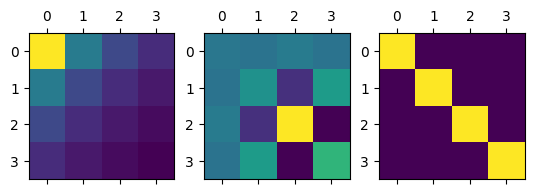

In [17]:
fig, axes = plt.subplots(1, 3)
axes[0].matshow(h)
axes[1].matshow(np.linalg.inv(h))
axes[2].matshow(np.linalg.inv(h) @ h)

In [49]:
def cool_hilbert_matrix(n: int) -> np.ndarray:
    k = np.arange(1, n+1).reshape(1, -1)
    return 1 / (k.T + k - 1)

# Exercise 8-10
- use function to make a matrix, compute it's inverse via `np.linalg.inv`
- find the product of the two matrices (should be identity matrix)
- compute the Euclidean distance between result and `np.eye` (should be ~0)
- put in a for loop over a range of matrix sizes from 3x3 to 12x12
- for each matrix store the Euclidean distance and the condition number
- Next use a Gaussian random matrix
- Plot distance to identity matrix and the condition number

In [51]:
h = cool_hilbert_matrix(4)
h @ np.linalg.inv(h)

array([[ 1.00000000e+00,  1.13686838e-13,  0.00000000e+00,
         0.00000000e+00],
       [-1.42108547e-14,  1.00000000e+00, -2.27373675e-13,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])

In [56]:
size_range = range(3, 13)
hilbert_results = np.zeros((2, len(size_range)))
gaussian_results = np.zeros((2, len(size_range)))
for i, size in enumerate(size_range):
    h = cool_hilbert_matrix(size)
    h_identity = h @ np.linalg.inv(h)
    hilbert_results[0, i] = np.linalg.norm(h_identity - np.eye(size, size))
    hilbert_results[1, i] = np.linalg.cond(h)

    g = np.random.default_rng().random((size, size))
    g_identity = g @ np.linalg.inv(g)
    gaussian_results[0, i] = np.linalg.norm(g_identity - np.eye(size, size))
    gaussian_results[1, i] = np.linalg.cond(g)

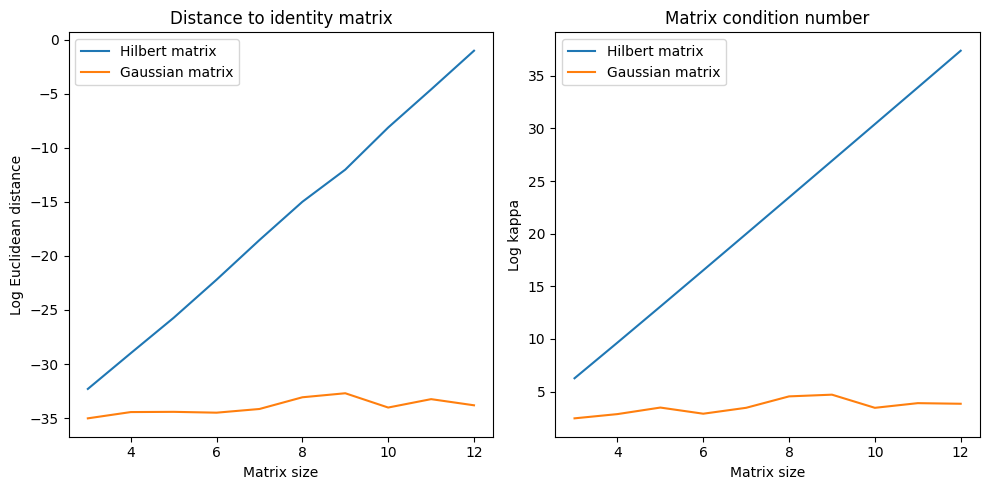

In [70]:
_, axes = plt.subplots(1, 2, figsize=(10, 5))
titles = ["Distance to identity matrix", "Matrix condition number"]
for i, title in enumerate(titles):
    axes[i].set_title(title)
    axes[i].plot(size_range, np.log(hilbert_results[i]))
    axes[i].plot(size_range, np.log(gaussian_results[i]))
    axes[i].set_xlabel("Matrix size")
    axes[i].legend(["Hilbert matrix", "Gaussian matrix"])


axes[0].set_ylabel("Log Euclidean distance")
axes[1].set_ylabel("Log kappa")

plt.tight_layout()

What this graph is showing us is the numerical instability of a Hilbert matrix as it gets larger in size